# 2.4 — Arbres de décision, forêts aléatoires et boosting

**Navigation** : [<< 2.3-Regression-lineaire-logistique](2.3-Regression-lineaire-logistique.ipynb) | [2.5-Biais-Variance-CV-ROC >>](2.5-Biais-Variance-CV-ROC.ipynb) | [Index](../README.md)

**Kernel** : Python 3

## Introduction

La régression linéaire et la régression logistique (notebook 2.3) tracent une **frontière de décision droite** : un hyperplan unique qui sépare les classes. Mais les données réelles sont rarement séparables par une simple droite. Les **arbres de décision** abordent le problème autrement : ils partitionnent l'espace des variables en régions délimitées par des coupures perpendiculaires aux axes (*axis-aligned*), ce qui capture des relations **non-linéaires** et des interactions entre variables. Le revers de la médaille : un seul arbre profond **surajuste** fortement. Les méthodes d'ensemble — **forêt aléatoire** et **gradient boosting** — réduisent cette variance en combinant de nombreux arbres.

### Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :
1. Ajuster un arbre de décision et observer le surapprentissage (accuracy d'entraînement proche de 1.0).
2. Visualiser une frontière de décision *axis-aligned* et reconnaître la signature « en escalier » d'un arbre profond.
3. Comprendre comment la forêt aléatoire réduit la variance (frontière plus lisse, meilleur score de test).
4. Comparer les trois familles : arbre seul, forêt aléatoire, gradient boosting.
5. Lire et interpréter l'importance des variables fournie par une forêt.

### Prérequis

- Notebook 2.1 (surapprentissage rendu visible).
- Notebook 2.3 (modèles linéaires : régression linéaire et logistique).

> **Référence.** Breiman, L., Friedman, J.H., Olshen, R.A. & Stone, C.J. (1984), *Classification and Regression Trees*, Wadsworth. Ouvrage fondateur de la méthode CART : un arbre partitionne récursivement l'espace des variables en régions homogènes par des coupures *axis-aligned*.

In [1]:
# Configuration et imports pour le notebook 2.4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)
# Figures compactes pour l'affichage
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 90

print("Configuration OK : 2.4 - Arbres, forets et boosting")

Configuration OK : 2.4 - Arbres, forets et boosting


## 1. Pourquoi les arbres de décision

La frontière de décision d'un modèle linéaire est **un seul hyperplan** (une droite en 2D) : elle ne peut pas épouser une structure non-linéaire. Un **arbre de décision** procède tout autrement : il pose une séquence de questions binaires du type « la variable $j$ est-elle supérieure au seuil $s$ ? ». Chaque réponse descend dans une branche ; les feuilles finales définissent des **régions rectangulaires emboîtées** qui partitionnent tout l'espace des variables.

Cette structure permet de capturer des **interactions** et des **frontières non-linéaires** qu'un modèle linéaire rate par construction. Nous allons le voir sur un jeu de données réel : le diagnostic du cancer du sein (sklearn `load_breast_cancer`), où les 30 variables descriptives (rayon, texture, périmètre, etc.) interagissent de façon complexe.

X_train : (398, 30)   X_test : (171, 30)
Nombre de variables : 30
Repartition des classes (y complet) : [212 357]
Classes : 0 = malignant, 1 = benign


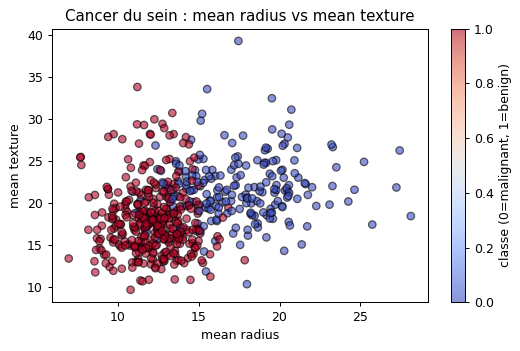

In [2]:
# Chargement du jeu de donnees cancer du sein (classification binaire reel)
cancer = load_breast_cancer()
X = cancer.data            # matrice (569, 30) : 30 variables quantitatives
y = cancer.target          # vecteur (569,) : classe 0 ou 1
noms_features = cancer.feature_names   # noms des 30 variables

# Division entrainement / test (70% / 30%) avec stratification par classe
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# cancer.target_names = ['malignant', 'benign']  =>  0 = malignant, 1 = benign
print(f"X_train : {X_train.shape}   X_test : {X_test.shape}")
print(f"Nombre de variables : {X.shape[1]}")
print(f"Repartition des classes (y complet) : {np.bincount(y)}")
print("Classes : 0 = malignant, 1 = benign")

# Apercu 2D : 2 premieres variables (mean radius, mean texture) colorees par classe
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", alpha=0.6)
plt.xlabel(noms_features[0])
plt.ylabel(noms_features[1])
plt.title("Cancer du sein : mean radius vs mean texture")
plt.colorbar(label="classe (0=malignant, 1=benign)")
plt.tight_layout()
plt.show()

## 2. Premier arbre de décision

Par défaut, un `DecisionTreeClassifier` croît jusqu'à sa profondeur maximale : il produit des feuilles **pures** sur l'ensemble d'entraînement. Conséquence directe : il **mémorise** les données vues (accuracy d'entraînement proche de 1.0) mais généralise moins bien. C'est exactement le surapprentissage du notebook 2.1, cette fois incarné par un arbre. L'**écart** entre l'accuracy d'entraînement et l'accuracy de test mesure la **variance** d'un arbre profond isolé.

In [3]:
# Arbre de decision par defaut : aucune limite de profondeur => arbre profond
arbre = DecisionTreeClassifier(random_state=42)
arbre.fit(X_train, y_train)

acc_train = accuracy_score(y_train, arbre.predict(X_train))
acc_test = accuracy_score(y_test, arbre.predict(X_test))

print(f"Arbre profond -- accuracy entrainement : {acc_train:.3f}")
print(f"Arbre profond -- accuracy test         : {acc_test:.3f}")
# train ~ 1.0 : l'arbre a memorise l'echantillon d'entrainement (surapprentissage).

Arbre profond -- accuracy entrainement : 1.000
Arbre profond -- accuracy test         : 0.918


## 3. La frontière de décision (concept-phare)

Un arbre trace des rectangles *axis-aligned*. Plus il est profond, plus il multiplie les coupures et plus sa frontière devient **brisée, en escalier** — elle épouse le bruit de l'échantillon. Pour visualiser ce comportement, nous nous restreignons à **deux variables** (`mean radius` et `mean texture`) et nous définissons une fonction utilitaire `frontiere_decision` qui trace la frontière d'un modèle sur ce plan 2D.

> **Astuce technique.** Le modèle complet est ajusté sur 30 variables, mais la visualisation ne porte que sur 2. La fonction ré-ajuste donc un modèle (du même type) sur les 2 variables seules afin que `predict` fonctionne sur la grille 2D : c'est le procédé standard pour visualiser une frontière, et il est honnête sur ce qu'il montre.

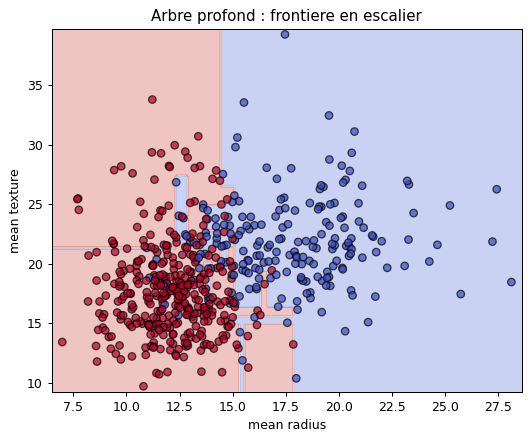

In [4]:
def frontiere_decision(modele, X_2d, y_2d, ax=None, titre=""):
    '''Trace la frontiere de decision d'un modele sur 2 features (meshgrid).

    Parametres
    ----------
    modele : estimateur sklearn
        Un modele DU MEME TYPE que celui etudie. Il est re-ajuste sur les 2
        features (X_2d) pour rendre la prediction sur la grille compatible.
    X_2d : array (n, 2)
        Les 2 colonnes a visualiser.
    y_2d : array (n,)
        Labels associes.
    ax : matplotlib Axes, optionnel
        Axes sur lesquels dessiner (pour les sous-figures cote a cote).
    titre : str
        Titre de la sous-figure.
    '''
    if ax is None:
        ax = plt.gca()
    # Grille couvrant l'espace des 2 features
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grille = np.c_[xx.ravel(), yy.ravel()]
    # Re-ajustement sur les 2 features pour la visualisation uniquement
    modele.fit(X_2d, y_2d)
    Z = modele.predict(grille).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm",
               edgecolors="k", alpha=0.7)
    ax.set_xlabel(noms_features[0])
    ax.set_ylabel(noms_features[1])
    ax.set_title(titre)

# Visualisation de l'arbre profond sur les 2 premieres features
X_2d = X[:, :2]  # 2 premieres features pour la visualisation
fig, ax = plt.subplots(figsize=(6, 5))
frontiere_decision(DecisionTreeClassifier(random_state=42), X_2d, y,
                   ax=ax, titre="Arbre profond : frontiere en escalier")
plt.tight_layout()
plt.show()
# La frontiere en escalier est la signature d'un arbre profond : des coupures
# axis-aligned qui epousent le bruit de l'echantillon.

### Exercice 1 : régler la profondeur maximale

Un arbre sans contrainte surajuste. Le paramètre `max_depth` limite la profondeur et régularise le modèle. **Objectif** : pour `max_depth` allant de 1 à 15, ajuster un `DecisionTreeClassifier(max_depth=p, random_state=42)` sur `X_train`/`y_train`, mesurer son **accuracy de test** sur `X_test`/`y_test`, puis identifier la profondeur qui maximise ce score.

**Indice** : stockez les accuracies de test dans une liste `acc_test_list`, puis utilisez `np.argmax(acc_test_list)` pour récupérer l'indice de la meilleure profondeur (à mapper vers `profondeurs`).

In [5]:
# Exercice 1 : trouver la profondeur maximale qui maximise l'accuracy de test
profondeurs = list(range(1, 16))

# TODO etudiant : boucler sur profondeurs, entrainer un
# DecisionTreeClassifier(max_depth=p, random_state=42) sur (X_train, y_train),
# puis mesurer accuracy_score(y_test, modele.predict(X_test)) pour chaque p.
acc_test_list = None  # TODO etudiant : remplacer (liste des accuracies de test)

# TODO etudiant : indice de la meilleure profondeur (np.argmax sur acc_test_list)
meilleure_profondeur = None  # TODO etudiant : remplacer

print(f"Exercice 1 a completer : meilleure profondeur = {meilleure_profondeur}")

Exercice 1 a completer : meilleure profondeur = None


## 4. Forêt aléatoire

La **forêt aléatoire** entraîne **un grand nombre d'arbres de décision**, chacun sur un **échantillon bootstrap** (tirage avec remise) des données, et en ne considérant qu'un **sous-ensemble aléatoire de variables** à chaque division. La prédiction finale est obtenue par **vote majoritaire** (classification). En moyennant de nombreux arbres à forte variance mais faible biais, la forêt **réduit la variance** sans augmenter beaucoup le biais : c'est le principe du *bagging*.

> **Référence.** Breiman, L. (2001), *Random Forests*, Machine Learning 45(1):5-32. Les forêts aléatoires combinent le bagging (échantillonnage bootstrap) et la sélection aléatoire de sous-ensembles de variables à chaque division pour décorréler les arbres et réduire la variance.

In [6]:
# Foret aleatoire : 100 arbres, vote majoritaire
foret = RandomForestClassifier(n_estimators=100, random_state=42)
foret.fit(X_train, y_train)

acc_train_foret = accuracy_score(y_train, foret.predict(X_train))
acc_test_foret = accuracy_score(y_test, foret.predict(X_test))

print(f"Foret -- accuracy entrainement : {acc_train_foret:.3f}")
print(f"Foret -- accuracy test         : {acc_test_foret:.3f}")
# L'accuracy de test est plus elevee et l'ecart train/test plus reduit
# que pour l'arbre seul (arbre) : la moyenne de 100 arbres reduit la variance.

Foret -- accuracy entrainement : 1.000
Foret -- accuracy test         : 0.936


## 5. Frontière de décision de la forêt (concept-phare)

Moyenner de nombreux arbres brisés produit une frontière **plus lisse**. La réduction de variance est **littéralement visible** en comparant côte à côte l'arbre seul et la forêt sur le même plan 2D.

> **Référence.** Hastie, T., Tibshirani, R. & Friedman, J. (2009), *The Elements of Statistical Learning*, Springer (2e éd.), §15.3. L'analyse théorique montre que la moyenne de $B$ arbres décorrélerés réduit la variance d'un facteur proche de $1/B$ lorsque les arbres sont peu corrélés : c'est le fondement quantitatif de la réduction de variance par *bagging*, que la figure suivante rend visible.

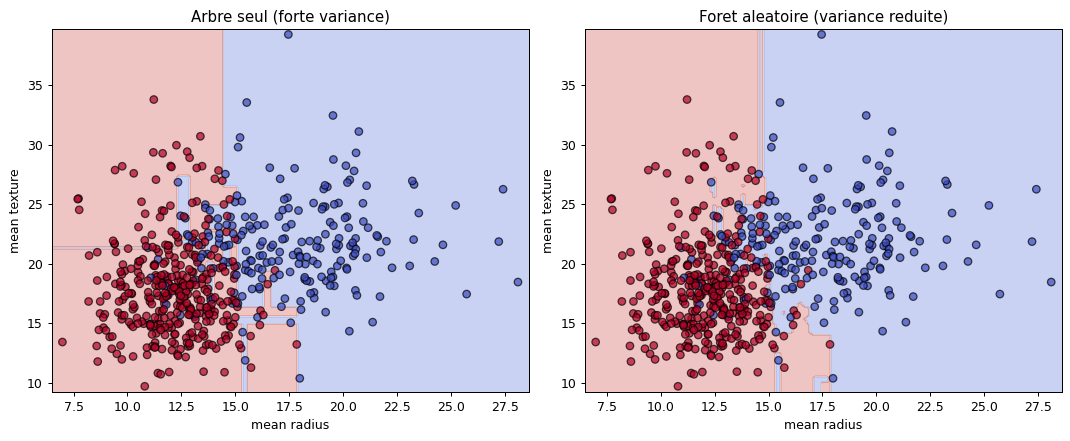

In [7]:
# Comparaison visuelle cote a cote : arbre seul vs foret aleatoire
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
frontiere_decision(DecisionTreeClassifier(random_state=42), X_2d, y,
                   ax=axes[0], titre="Arbre seul (forte variance)")
frontiere_decision(RandomForestClassifier(n_estimators=100, random_state=42),
                   X_2d, y, ax=axes[1],
                   titre="Foret aleatoire (variance reduite)")
plt.tight_layout()
plt.show()
# La frontiere de droite est manifestement plus lisse : la moyenne des arbres
# lisse les coupures individuelles et epouse mieux la structure reelle.

## 6. Importance des variables

Une forêt aléatoire expose l'attribut `feature_importances_` : la diminution moyenne d'impureté (Gini) apportée par chaque variable, cumulée sur tous les arbres. C'est un bénéfice pratique majeur : un **classement interprétable** des variables, même avec 30 descripteurs. La forêt nous dit quelles mesures anatomiques portent le plus de signal diagnostique.

Top 10 variables les plus importantes :
   1. worst concave points           0.1590
   2. worst area                     0.1470
   3. worst perimeter                0.0858
   4. worst radius                   0.0790
   5. mean radius                    0.0777
   6. mean perimeter                 0.0742
   7. mean concave points            0.0659
   8. mean concavity                 0.0543
   9. mean area                      0.0417
  10. worst concavity                0.0314


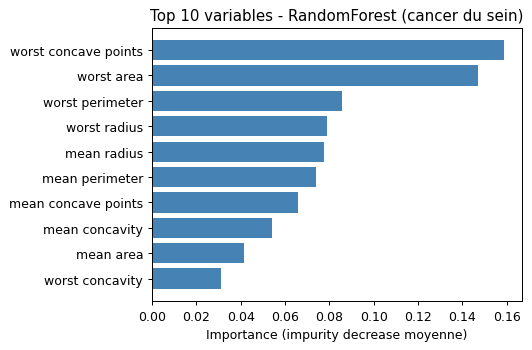

In [8]:
# Importance des variables selon la foret (diminution moyenne d'impurete)
importances = foret.feature_importances_
ordre = np.argsort(importances)[::-1]   # du plus important au moins important

# Top 10 des variables les plus importantes
top_n = 10
top_indices = ordre[:top_n]
top_noms = noms_features[top_indices]
top_vals = importances[top_indices]

print("Top 10 variables les plus importantes :")
for rang, (nom, val) in enumerate(zip(top_noms, top_vals), start=1):
    print(f"  {rang:2d}. {nom:<30s} {val:.4f}")

# Diagramme en barres horizontales (du moins important au plus important en haut)
plt.figure()
plt.barh(range(top_n), top_vals[::-1], color="steelblue")
plt.yticks(range(top_n), top_noms[::-1])
plt.xlabel("Importance (impurity decrease moyenne)")
plt.title("Top 10 variables - RandomForest (cancer du sein)")
plt.tight_layout()
plt.show()

### Exercice 2 : identifier la variable la plus importante

**Objectif** : extraire les importances de la forêt `foret`, trouver l'indice de la variable la plus importante, et renvoyer son nom depuis `noms_features`.

**Étapes**
1. Récupérez `foret.feature_importances_`.
2. Calculez l'indice du maximum avec `np.argmax`.
3. Mappez cet indice vers le nom via `noms_features[indice_top]`.

In [9]:
# Exercice 2 : trouver la variable la plus importante selon la foret
# TODO etudiant : extraire les importances de la foret
importances_ex = None  # TODO etudiant : remplacer (foret.feature_importances_)

# TODO etudiant : indice de la variable la plus importante (np.argmax)
indice_top = None  # TODO etudiant : remplacer

# TODO etudiant : nom de cette variable dans noms_features
nom_top = None  # TODO etudiant : remplacer

print(f"Exercice 2 a completer : variable la plus importante = {nom_top}")

Exercice 2 a completer : variable la plus importante = None


## 7. Gradient Boosting

Contrairement à la forêt (arbres **indépendants** puis moyenne), le **boosting** entraîne les arbres **séquentiellement** : chaque nouvel arbre corrige les **erreurs résiduelles** de l'ensemble jusqu'ici. On construit ainsi un modèle additif à **faible biais**, incrément par incrément. Sans contrainte (trop d'estimateurs), il peut lui aussi surajuster.

> **Référence.** Friedman, J.H. (2001), *Greedy Function Approximation: A Gradient Boosting Machine*, Annals of Statistics 29(5):1189-1232. Le boosting construit un modèle additif par descente de gradient dans l'espace des fonctions : chaque arbre corrige les erreurs résiduelles du précédent.

In [10]:
# Gradient boosting : arbres additifs sequentiels (correction des residus)
boosting = GradientBoostingClassifier(random_state=42)
boosting.fit(X_train, y_train)

acc_test_boosting = accuracy_score(y_test, boosting.predict(X_test))

print(f"Boosting -- accuracy test : {acc_test_boosting:.3f}")

Boosting -- accuracy test : 0.947


### Exercice 3 : comparer les trois modèles

**Objectif** : calculer l'accuracy de test des trois modèles `arbre`, `foret` et `boosting` sur `X_test`/`y_test`, les rassembler dans une structure de comparaison, et identifier le meilleur.

**Indice** : un dictionnaire `{"arbre": ..., "foret": ..., "boosting": ...}` puis `max(comparaison, key=comparaison.get)`.

In [11]:
# Exercice 3 : comparer l'accuracy de test des 3 modeles (arbre, foret, boosting)
# TODO etudiant : pour chaque modele, calculer accuracy_score(y_test, modele.predict(X_test))
acc_arbre = None      # TODO etudiant : remplacer (accuracy_score(y_test, arbre.predict(X_test)))
acc_foret = None      # TODO etudiant : remplacer
acc_boosting = None   # TODO etudiant : remplacer

comparaison = None    # TODO etudiant : remplacer (ex dict {"arbre": acc_arbre, ...})

# TODO etudiant : nom du meilleur modele
meilleur_modele = None  # TODO etudiant : remplacer

print(f"Exercice 3 a completer : meilleur modele = {meilleur_modele}")

Exercice 3 a completer : meilleur modele = None


## Conclusion et transition

Les **arbres de décision** capturent la non-linéarité en partitionnant l'espace en régions *axis-aligned*, mais un arbre profond isolé **surajuste** (forte variance, frontière en escalier). La **forêt aléatoire** réduit cette variance en moyennant de nombreux arbres : frontière plus lisse, meilleure accuracy de test, et bonus — l'**importance des variables**. Le **gradient boosting** construit quant à lui un modèle additif séquentiel qui corrige les résidus, atteignant un faible biais. Les trois dépassent ce que permettaient les modèles linéaires du notebook 2.3.

Le prochain notebook, `2.5-Biais-Variance-CV-ROC`, formalise le **compromis biais-variance**, introduit la **validation croisée** pour une estimation fiable des performances, et la **courbe ROC** pour évaluer un classifieur au-delà de la simple accuracy.

## References

1. Breiman, L., Friedman, J.H., Olshen, R.A. & Stone, C.J. (1984). *Classification and Regression Trees*. Wadsworth. — Méthode CART : arbres de décision par partitionnement récursif *axis-aligned*.
2. Breiman, L. (2001). *Random Forests*. Machine Learning 45(1):5-32. — Forêts aléatoires : bagging + sélection aléatoire de variables, réduction de variance.
3. Friedman, J.H. (2001). *Greedy Function Approximation: A Gradient Boosting Machine*. Annals of Statistics 29(5):1189-1232. — Gradient boosting : modèle additif séquentiel par descente de gradient.
4. Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer (2e éd.), §§9.2, 10.1, 15.3. — Arbres, forêts, boosting et compromis biais-variance.
5. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research 12:2825-2830. — `DecisionTreeClassifier`, `RandomForestClassifier`, `GradientBoostingClassifier`.